# Tuned ElasticNet Regression Model
## T3 Immunological Data
### Targets: pain_reduction_pct 


In [5]:
import sys, os
sys.path.insert(0, '../../src')
import joblib
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skrub import TableReport
import preprocess
import explore
import model
import model_elasticnet
from sklearn.preprocessing import PowerTransformer
os.environ['PYTHONWARNINGS'] = 'ignore'
MODEL_DIR = os.path.abspath('../../models/pain-reduction')


In [2]:
# Running through preprocessing steps
df_im, df_cl = explore.load_data()

# Clean datasets
_im_id_cols = ['Patient', 'Timepoint', 'Date']
df_im_vis   = preprocess.clean_im(df_im, False)
df_cl_vis   = preprocess.clean_cl(df_cl, False)

# Immunological: drop >25% NaN columns, remove confirmed outliers
df_im_mod    = preprocess.remove_nan_cols(df_im_vis, verbose=False)
df_im_mod    = preprocess.remove_outlier_observations(df_im_mod, verbose=False)
df_im_mod    = preprocess.remove_for_modeling(df_im_mod, verbose=False)
# Clinical: drop >25% NaN columns
df_cl_mod    = preprocess.remove_nan_cols(df_cl_vis, verbose=False)
df_cl_mod    = preprocess.remove_outlier_observations(df_cl_mod, verbose=False)
df_cl_mod    = preprocess.remove_for_modeling(df_cl_mod, verbose=False)

In [3]:
# Creating Target for pain scale
print('\nConstructing regression targets from clinical data')
pain_targets       = model.construct_datasets_targets(df_cl_mod, 'pain_scale',      [1,3])

# Constructing dataset for modeling with targets and im + cl data
print('\nConstructing datasets for modeling:')
df_pain = model.create_model_datasets(df_im_mod, df_cl_mod, pain_targets, timepoints=[3])

pt = PowerTransformer(method='yeo-johnson', standardize=True)



Constructing regression targets from clinical data

  Target distributions:
    pain_reduction                              mean=2.218  std=2.424  [-3.500, 8.300]
    pain_reduction_pct                          mean=32.359  std=34.769  [-87.500, 88.235]

Constructing datasets for modeling:

Modeling dataset ready: T3 features + clinical features
Shape: (91, 95),  Patients: 91


## Dataset Overview

In [2]:
# Censored from Gitlab
#TableReport(df_pain, max_plot_columns=100)

# Correlation between Features and Target (T3)

In [4]:
# Correlations between target and features in the dataset
importlib.reload(explore)
ex_cols = ['Patient', 'Timepoint','pain_reduction']

explore.target_correlation(
    df_pain,
    target_col='pain_reduction_pct',
    ex_cols=ex_cols,
    name='Modeling Dataset and Target Correlations', plot=False)


Target Correlation (Modeling Dataset and Target Correlations)    Target: pain_reduction_pct

Positive Correlations with pain_reduction_pct (> 0.05):
  Feature                                       Method      Correlation
  -----------------------------------------------------------------
  TC CM_PD1+_t3                                 Spearman         0.2106
  TH EM_PD1+_t3                                 Spearman         0.1666
  Neu_HLADR+_t3                                 Spearman         0.1641
  TH_PD1+_t3                                    Spearman         0.1462
  TH CM_PD1+_t3                                 Spearman         0.1374
  TH_HLADR+_t3                                  Spearman         0.1301
  Mo1_HLADRhi_t3                                Spearman         0.1287
  Mo_HLADRhi_t3                                 Spearman         0.1275
  TH_HLADRhi_t3                                 Spearman         0.1257
  Mo1_HLADR+_t3                                 Spearman      

,Feature,Method,Correlation,Abs_correlation,p_value
0,overweight,Phik,0.4437,0.4437,NaN
1,NK cells_t3,Spearman,-0.2217,0.2217,0.0347
2,TC CM_PD1+_t3,Spearman,0.2106,0.2106,0.0560
3,NKT_16+_t3,Spearman,-0.1854,0.1854,0.0786
4,NK_CD8+_t3,Spearman,-0.1735,0.1735,0.1001
...,...,...,...,...,...
87,NLR_t3,Spearman,-0.0029,0.0029,0.9779
88,gender,Phik,0.0000,0.0000,NaN
89,diagnosis,Phik,0.0000,0.0000,NaN
90,target_volume,Phik,0.0000,0.0000,NaN


## Elasticnet + MRMR Feature selection 
### Nested CV and Optuna hyperparameter tuning

### Target: pain_reduction_pct

In [6]:
importlib.reload(model_elasticnet)
_, en_feature_freq3, en_sel_per_fold3 = model_elasticnet.elasticnet_mrmr(
        df_pain,
        target_col='pain_reduction_pct',
        random_state=42,
        target_transformer=pt)

# Save feature frequency list and selections per outer fold:
joblib.dump(en_feature_freq3,         os.path.join(MODEL_DIR, 'en_feature_freq3.pkl'))
joblib.dump(en_sel_per_fold3,         os.path.join(MODEL_DIR, 'en_sel_per_fold3.pkl'))



 Nested CV - ElasticNet + MRMR + Optuna — pain_reduction_pct
  n=91, p=92
  Outer 4x5=20 | Inner 4x5=20 | Optuna Trials Model=50 | Optuna Trials MRMR=20

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
    MRMR Trial  1/20: RMSE=1.1535  {'K': 15, 'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 14}
    MRMR Trial  2/20: RMSE=1.1535  {'K': 20, 'n_estimators': 100, 'max_depth': 4, 'min_samples_leaf': 13}
    MRMR Trial  3/20: RMSE=1.1535  {'K': 20, 'n_estimators': 400, 'max_depth': 7, 'min_samples_leaf': 8}
    MRMR Trial  4/20: RMSE=1.1535  {'K': 15, 'n_estimators': 400, 'max_depth': 8, 'min_samples_leaf': 17}
    MRMR Trial  5/20: RMSE=1.1535  {'K': 20, 'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 9}
    MRMR Trial  6/20: RMSE=1.1535  {'K': 10, 'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 19}
    MRMR Trial  7/20: RMSE=1.1535  {'K': 15, 'n_estimators': 

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\pain-reduction\\en_sel_per_fold3.pkl']

## Plot of Feature Frequency List 
Top 25 Features Selections Shown.

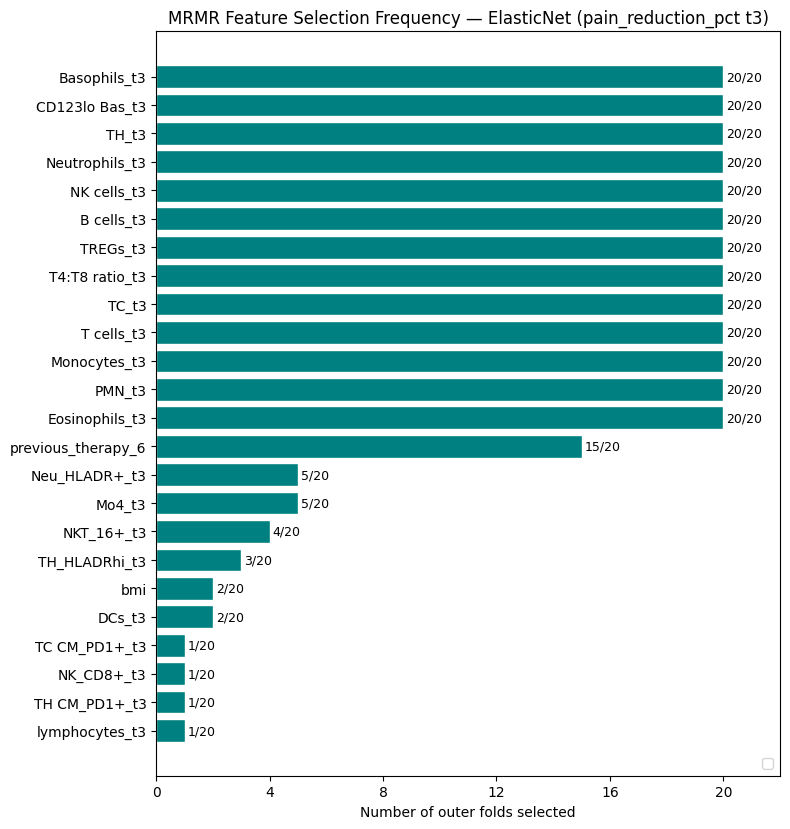

In [ ]:
feature_list = joblib.load(os.path.join(MODEL_DIR, 'en_feature_freq3.pkl'))
model.plot_feature_frequency(feature_list, name='ElasticNet (pain_reduction_pct t3)', top=25)

## Jaccard Score of MRMR Selected Features
### Pairwise (20 Outer Folds x 20 Outer Folds)  Comparisons


  Jaccard Scores — ElasticNet (MRMR Feat. Sel.) t3
  Folds: 20   Pairs evaluated: 190
  Mean Jaccard : 0.845 ± 0.065
  Min  Jaccard : 0.765
  Max  Jaccard : 1.000


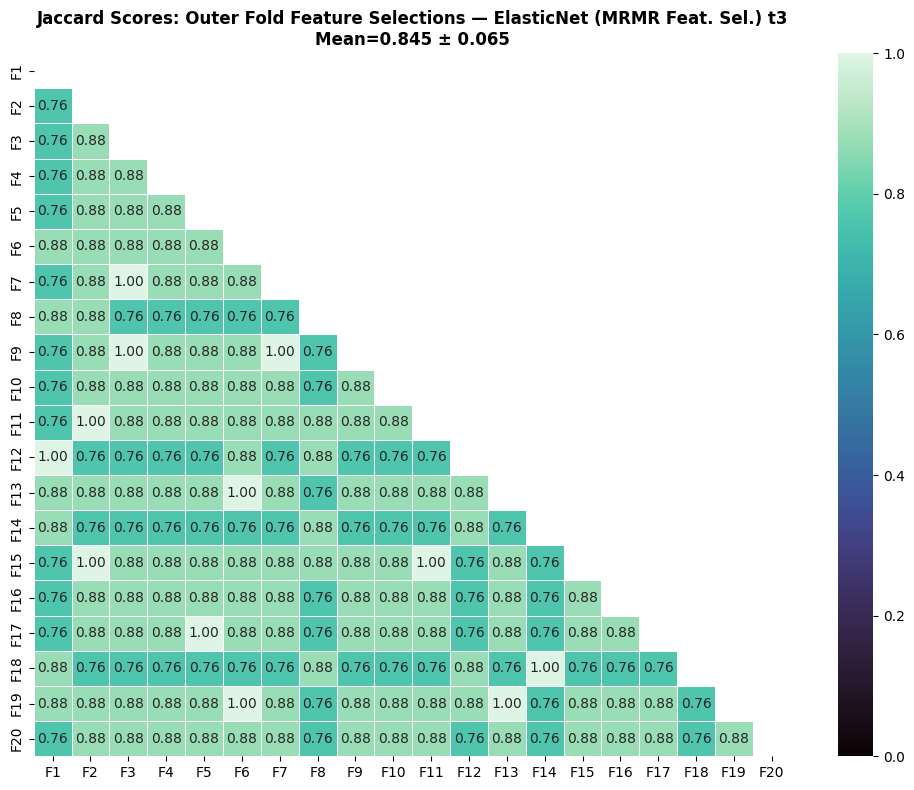

In [ ]:
selected_per_fold = joblib.load(os.path.join(MODEL_DIR, 'en_sel_per_fold3.pkl'))
jac_matrix = model.jaccard_scores(selected_per_fold, name='ElasticNet (MRMR Feat. Sel.) t3')

#### Using MRMR Selected Features Moving Forward

 # ElasticNet on Different Subsets of Selected Features
 ## Target: pain_reduction_pct

In [7]:
importlib.reload(model_elasticnet)
feature_list3 = joblib.load(os.path.join(MODEL_DIR, 'en_feature_freq3.pkl'))

en_sweep_df3 = model_elasticnet.elasticnet_threshold_analysis(
     df_pain, 
     feature_list3, 
     target_col='pain_reduction_pct',
     random_state=42, 
     target_transformer=pt)
joblib.dump(en_sweep_df3,      os.path.join(MODEL_DIR, 'en_sweep_df3.pkl'))



  Threshold  all ( ):  94 features
  ['PMN_t3', 'TH_t3', 'Neutrophils_t3', 'NK cells_t3', 'B cells_t3', 'TREGs_t3', 'T4:T8 ratio_t3', 'TC_t3']...
  Outer Fold  1/20:  Best Trial 16/50  RMSE=0.9868  {'alpha': 0.3168802090904894, 'l1_ratio': 0.708270914552678}
  Outer Fold  2/20:  Best Trial 12/50  RMSE=1.0049  {'alpha': 7.041830285015986, 'l1_ratio': 0.005297120813991968}
  Outer Fold  3/20:  Best Trial 13/50  RMSE=1.0133  {'alpha': 1.7907854345319008, 'l1_ratio': 0.3438675441130149}
  Outer Fold  4/20:  Best Trial 13/50  RMSE=1.0027  {'alpha': 8.19260227903101, 'l1_ratio': 0.3438675441130149}
  Outer Fold  5/20:  Best Trial 13/50  RMSE=1.0069  {'alpha': 1.7907854345319008, 'l1_ratio': 0.3438675441130149}
  Outer Fold  6/20:  Best Trial 13/50  RMSE=1.0078  {'alpha': 1.7907854345319008, 'l1_ratio': 0.3438675441130149}
  Outer Fold  7/20:  Best Trial 13/50  RMSE=1.0175  {'alpha': 1.7907854345319008, 'l1_ratio': 0.3438675441130149}
  Outer Fold  8/20:  Best Trial 13/50  RMSE=1.0028  {'alp

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\pain-reduction\\en_sweep_df3.pkl']

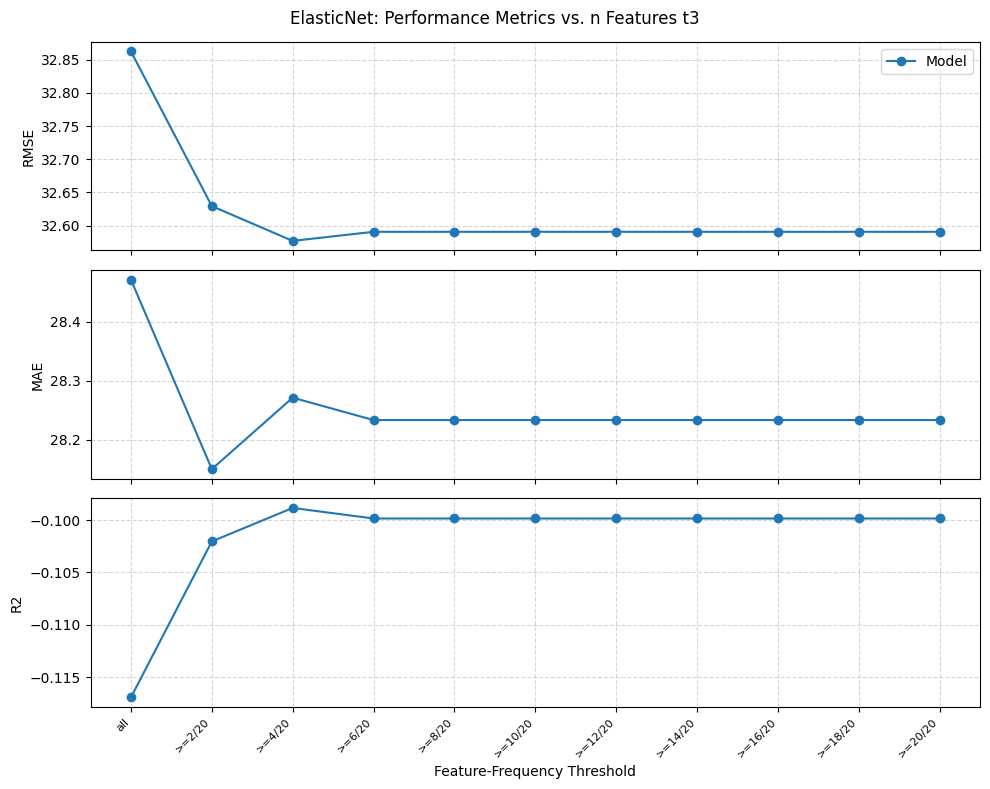

In [12]:
# Plot performances on different feature-tresholds
importlib.reload(model)
model.plot_sweep(en_sweep_df3, title='ElasticNet: Performance Metrics vs. n Features t3')

# ____________________________________________________________________________
## Final ElasticNet Model 
### Using Features Selected in More Than 4/20 Outer Folds

In [8]:
en_feature_freq = joblib.load(os.path.join(MODEL_DIR, 'en_feature_freq3.pkl'))
# selecting features in more than 14/20 outer folds:
sel_features3 = en_feature_freq[en_feature_freq >= 4].index.tolist()

en_results_df3, en_model3, en_X_final3, en_y_pred3, en_patient_err3, en_err_df3, en_scaler3, en_errors3 = model_elasticnet.run_tuned_elasticnet(
    df_pain, 
    sel_features3,
    target_col='pain_reduction_pct', 
    random_state=42,
    target_transformer=pt)

# save results
joblib.dump(en_results_df3,                os.path.join(MODEL_DIR, 'en_results_df3.pkl'))
joblib.dump(en_model3,                os.path.join(MODEL_DIR, 'en_model3.pkl'))
joblib.dump(en_X_final3,              os.path.join(MODEL_DIR, 'en_X_final3.pkl'))
joblib.dump(en_patient_err3,          os.path.join(MODEL_DIR, 'en_patient_err3.pkl'))
joblib.dump(en_err_df3,               os.path.join(MODEL_DIR, 'en_err_df3.pkl'))
joblib.dump(en_scaler3,               os.path.join(MODEL_DIR, 'en_scaler3.pkl'))
joblib.dump(en_errors3,               os.path.join(MODEL_DIR, 'en_errors3.pkl'))


  ElasticNet + Optuna — pain_reduction_pct
  n=91, p=17
  Outer 4x5=20 | Inner 4x5=20 | Optuna trials Model=50

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
    Trial   1/50: RMSE=1.2392  {'alpha': 0.0074593432857265485, 'l1_ratio': 0.9507143064099162}
    Trial   2/50: RMSE=1.0136  {'alpha': 0.4570563099801455, 'l1_ratio': 0.5986584841970366}
    Trial   3/50: RMSE=1.3113  {'alpha': 0.0006026889128682511, 'l1_ratio': 0.15599452033620265}
    Trial   4/50: RMSE=1.3226  {'alpha': 0.00019517224641449495, 'l1_ratio': 0.8661761457749352}
    Trial   5/50: RMSE=1.0922  {'alpha': 0.10129197956845731, 'l1_ratio': 0.7080725777960455}
    Trial   6/50: RMSE=1.3237  {'alpha': 0.00012674255898937226, 'l1_ratio': 0.9699098521619943}
    Trial   7/50: RMSE=1.0115  {'alpha': 1.452824663751602, 'l1_ratio': 0.21233911067827616}
    Trial   8/50: RMSE=1.3072  {'alpha': 0.0008111941985431928, 'l1_ra

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\pain-reduction\\en_errors3.pkl']

## Difficult Patient-Predictions

In [11]:
patient_err = joblib.load(os.path.join(MODEL_DIR, 'en_patient_err3.pkl'))
print(patient_err.to_string())

         mean_mae  mean_true  mean_pred  n_folds
Patient                                         
239         63.61     -30.77      32.84        5
72          61.40     -27.78      33.62        5
92          60.33     -26.23      34.10        5
207         58.27      88.24      29.96        5
181         56.89      87.50      30.61        5
95          56.07      86.36      30.29        5
172         54.47     -16.67      37.81        5
58          51.72      83.00      31.28        5
154         51.49      83.33      31.85        5
112         49.86      83.33      33.48        5
126         48.27      79.75      31.48        5
159         47.65     -14.29      33.36        5
16          46.99     -14.29      32.71        5
212         46.43      76.92      30.49        5
261         43.95      76.92      32.97        5
205         43.77      75.00      31.23        5
128         43.68      78.16      34.48        5
109         43.64      75.00      31.36        5
185         42.82   

In [15]:
# Pain Values for top 10 difficult patient predictions:
difficult_patients = patient_err.head(10).index.tolist()

pain_data = (df_cl_mod[df_cl_mod['Patient'].isin(difficult_patients)]
             [['Patient', 'Timepoint', 'pain_scale']].pivot(index='Patient', columns='Timepoint', values='pain_scale'))
pain_data.columns = [f'pain_t{c}' for c in pain_data.columns]

difficult_df = (pain_data
                .merge(patient_err[['mean_mae']], left_index=True, right_index=True)
                .sort_values('mean_mae', ascending=False))[['pain_t1', 'pain_t3', 'mean_mae']]


print('Difficult Patient-Predictions and Pain Scale Values:')
display(difficult_df)

Difficult Patient-Predictions and Pain Scale Values:


,pain_t1,pain_t3,mean_mae
Patient,,,
239,6.5,8.5,63.61
72,1.8,2.3,61.40
92,6.1,7.7,60.33
207,8.5,1.0,58.27
181,8.0,1.0,56.89
95,2.2,0.3,56.07
172,6.0,7.0,54.47
58,10.0,1.7,51.72
154,6.0,1.0,51.49


## Prediction-Error Heatmap

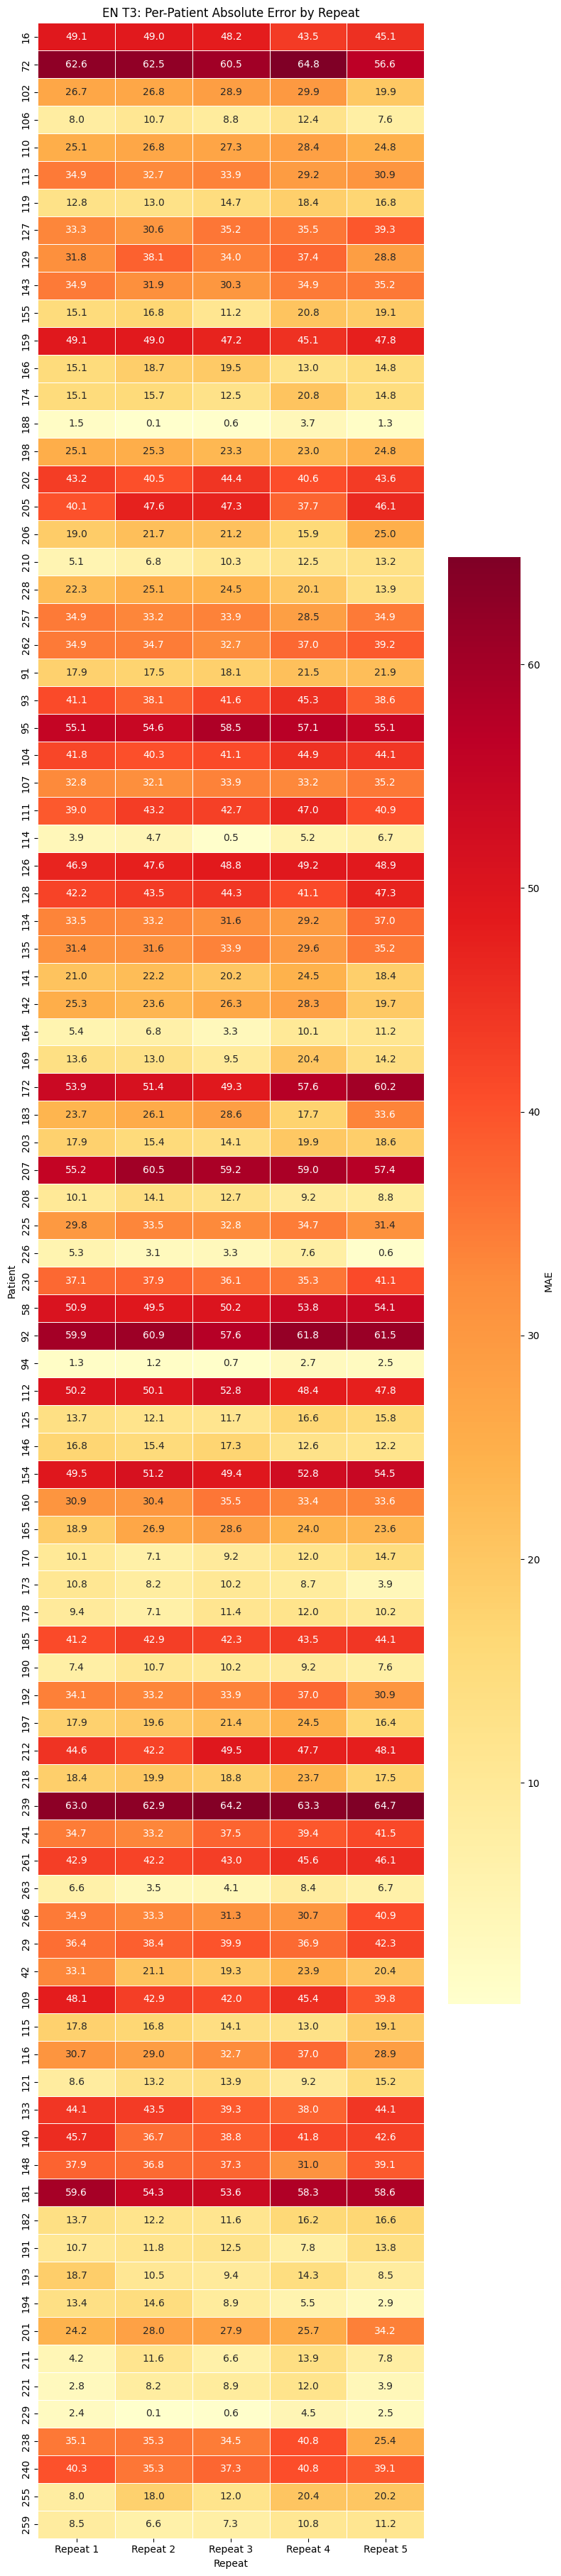

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
seen = []

for e in en_errors3:
    if e['Patient'] not in seen:
        seen.append(e['Patient'])

heatmap_data = en_err_df3.loc[seen]

fig, ax = plt.subplots(figsize=(8, max(4, len(heatmap_data) * 0.4)))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'MAE'})
ax.set_title('EN T3: Per-Patient Absolute Error by Repeat')
ax.set_xlabel('Repeat')
ax.set_ylabel('Patient')
plt.tight_layout()
plt.show()

## SHAP-values Plot


=== SHAP Analysis: Elasticnet ===


Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

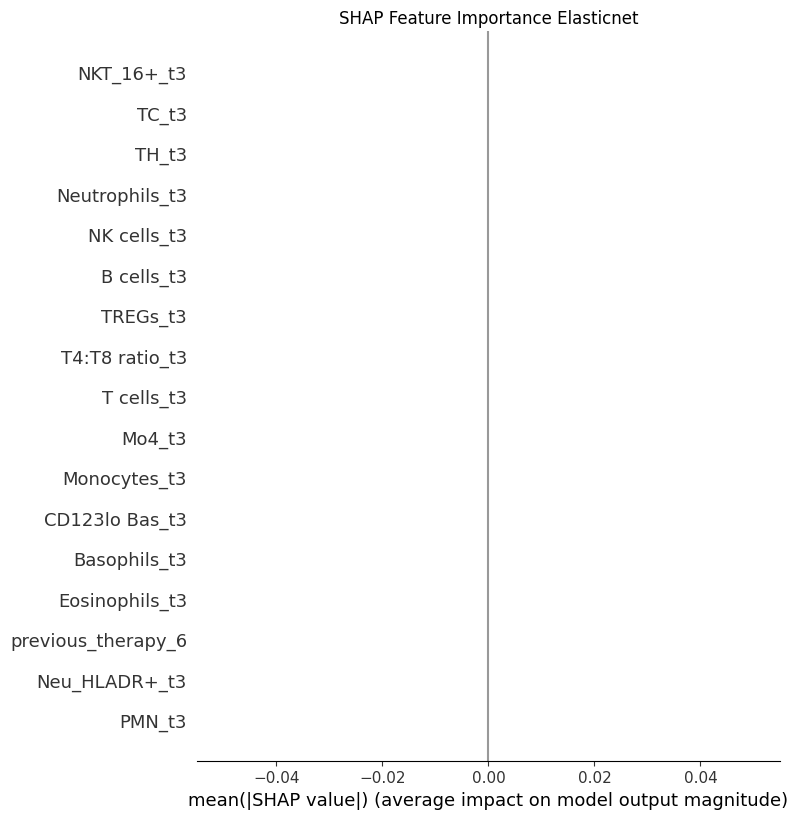

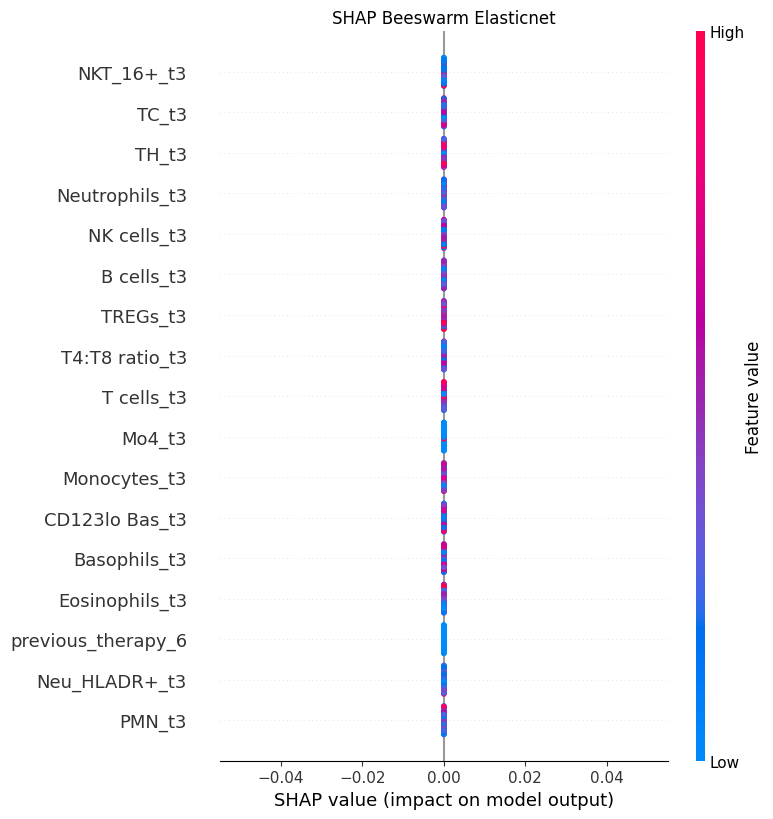

In [10]:
# Plot Shap values
en_model= joblib.load(os.path.join(MODEL_DIR, 'en_model3.pkl'))
en_X_final = joblib.load(os.path.join(MODEL_DIR, 'en_X_final3.pkl'))
en_scaler = joblib.load(os.path.join(MODEL_DIR, 'en_scaler3.pkl'))

en_shap = model.plot_shap_elasticnet(en_model, en_X_final, en_scaler)


## Dummy Model

In [ ]:
en_dummy_results = model_elasticnet.run_dummy_enet(
    df_pain,
    target_col='pain_reduction_pct',
    random_state=42,       
    target_transformer=pt)